# Churn Analysis

#### This analysis seeks to answer the following hypotheses: 
*1. Do customers with late deliveries churn?*

*2. Do low review scores increase churn?*

*3. Do states with worse delivery times have lower retention?*

*4. Do premium customers tolerate more delays?*

*5. Does frequency affect satisfaction?*

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

In [2]:
load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

try:
    folder = r"C:\Professional_project\Churn_and_Marketing_Analytics\Script_SQL"
    file = "dataset_exploration.sql"
    path = os.path.join(folder, file)
    
    with open(path, "r", encoding="utf-8") as f:
        sql = f.read()

    engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}')

    churn_df = pd.read_sql(sql, con=engine)
    print("The data has been successfully loaded!!!")
    
except FileNotFoundError:
    print(f"The file was not found in the path:{path}")

except Exception as e:
    print(f'--Error details--: {e}')

finally:
    engine.dispose()

The data has been successfully loaded!!!


### Dataset cleaning

In [3]:
churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95420 entries, 0 to 95419
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_unique_id        95420 non-null  str    
 1   avg_order_value           95420 non-null  float64
 2   customer_state            95420 non-null  str    
 3   total_orders              95420 non-null  int64  
 4   total_spent               95419 non-null  float64
 5   avg_payment_installments  95419 non-null  float64
 6   avg_review_score          94721 non-null  float64
 7   avg_delivery_delay_days   93356 non-null  float64
 8   last_purchase             95420 non-null  object 
 9   first_purchase            95420 non-null  object 
 10  customer_lifetime_days    95420 non-null  int64  
 11  recency_days              95420 non-null  int64  
 12  churn_flag                95420 non-null  int64  
dtypes: float64(5), int64(4), object(2), str(2)
memory usage: 9.5+ MB


In [4]:
churn_df.isnull().sum()

customer_unique_id             0
avg_order_value                0
customer_state                 0
total_orders                   0
total_spent                    1
avg_payment_installments       1
avg_review_score             699
avg_delivery_delay_days     2064
last_purchase                  0
first_purchase                 0
customer_lifetime_days         0
recency_days                   0
churn_flag                     0
dtype: int64

In [5]:
churn_df["last_purchase"] = pd.to_datetime(churn_df["last_purchase"])
churn_df["first_purchase"] = pd.to_datetime(churn_df["first_purchase"])

In [6]:
churn_df.describe()

,avg_order_value,total_orders,total_spent,avg_payment_installments,avg_review_score,avg_delivery_delay_days,last_purchase,first_purchase,customer_lifetime_days,recency_days,churn_flag
count,95420.000000,95420.000000,95419.000000,95419.000000,94721.000000,93356.000000,95420,95420,95420.000000,95420.000000,95420.000000
mean,214.240040,1.034018,164.505251,2.918697,4.102488,-11.849300,2018-01-02 11:57:54,2017-12-30 19:33:49,2.683389,243.501457,0.604926
min,10.070000,1.000000,4.070000,0.000000,1.000000,-147.000000,2016-09-04 00:00:00,2016-09-04 00:00:00,0.000000,0.000000,0.000000
25%,64.090000,1.000000,62.280000,1.000000,4.000000,-17.000000,2017-09-15 00:00:00,2017-09-12 00:00:00,0.000000,119.000000,0.000000
50%,113.165000,1.000000,106.870000,2.000000,5.000000,-12.000000,2018-01-22 00:00:00,2018-01-19 00:00:00,0.000000,224.000000,1.000000
75%,201.982500,1.000000,181.680000,4.000000,5.000000,-7.000000,2018-05-07 00:00:00,2018-05-04 00:00:00,0.000000,353.000000,1.000000
max,109312.640000,16.000000,13664.080000,24.000000,5.000000,188.000000,2018-09-03 00:00:00,2018-08-29 00:00:00,633.000000,729.000000,1.000000
std,643.698682,0.211234,226.734020,2.692747,1.326391,10.140626,NaN,NaN,25.263074,153.160850,0.488869


In [7]:
churn_df = churn_df.dropna(subset=["avg_delivery_delay_days"])

In [8]:
churn_df["avg_review_score"] = (
    churn_df["avg_review_score"]
    .fillna(churn_df["avg_review_score"].median())
)

In [9]:
churn_df.dropna(inplace=True)

In [10]:
churn_df.info()

<class 'pandas.DataFrame'>
Index: 93355 entries, 0 to 95419
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype        
---  ------                    --------------  -----        
 0   customer_unique_id        93355 non-null  str          
 1   avg_order_value           93355 non-null  float64      
 2   customer_state            93355 non-null  str          
 3   total_orders              93355 non-null  int64        
 4   total_spent               93355 non-null  float64      
 5   avg_payment_installments  93355 non-null  float64      
 6   avg_review_score          93355 non-null  float64      
 7   avg_delivery_delay_days   93355 non-null  float64      
 8   last_purchase             93355 non-null  datetime64[s]
 9   first_purchase            93355 non-null  datetime64[s]
 10  customer_lifetime_days    93355 non-null  int64        
 11  recency_days              93355 non-null  int64        
 12  churn_flag                93355 non-null  int64 

In [11]:
churn_df.isnull().sum()

customer_unique_id          0
avg_order_value             0
customer_state              0
total_orders                0
total_spent                 0
avg_payment_installments    0
avg_review_score            0
avg_delivery_delay_days     0
last_purchase               0
first_purchase              0
customer_lifetime_days      0
recency_days                0
churn_flag                  0
dtype: int64

### Churn distribution

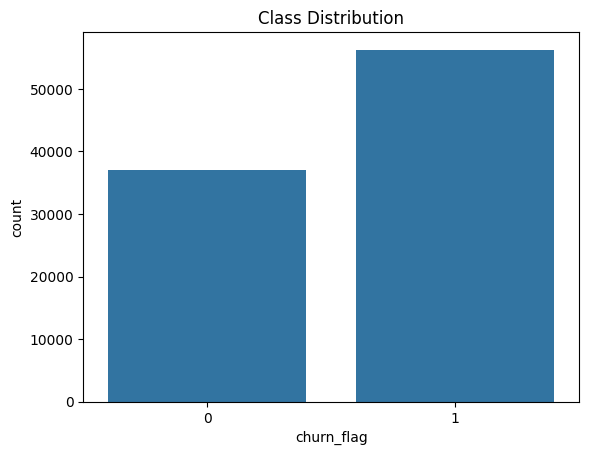

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="churn_flag", data=churn_df)
plt.title("Class Distribution")

plt.show()

*The customer base shows a relatively high level of inactivity. Approximately 55% of customers did not make a purchase within the last +180 days of the observation period and were classified as churned, while the remaining 45% remained active. This suggests that customer retention may be a significant challenge for the business and justifies further investigation into the factors associated with customer churn.*

### Delivery Delay vs Churn

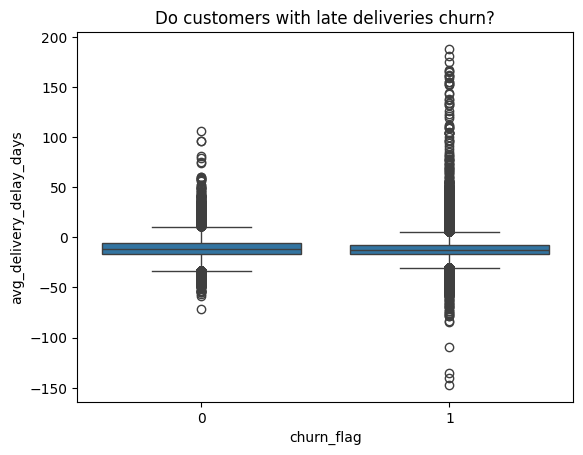

In [13]:
sns.boxplot(
    x="churn_flag",
    y="avg_delivery_delay_days",
    data=churn_df)

plt.title("Do customers with late deliveries churn?")

plt.show()

*The distribution of average delivery delays is remarkably similar between churned and active customers. Most customers in both groups received their orders before the estimated delivery date, as indicated by the negative median delay values. However, churned customers exhibit a higher number of extreme positive delays, suggesting that severe delivery disruptions may contribute to customer attrition.*

In [14]:
churn_df.groupby("churn_flag")["avg_delivery_delay_days"].describe()

,count,mean,std,min,25%,50%,75%,max
churn_flag,,,,,,,,
0,37056.0,-11.886298,9.584722,-71.0,-17.0,-12.0,-6.0,106.0
1,56299.0,-11.825798,10.488623,-147.0,-17.0,-13.0,-8.0,188.0


### Review Score vs Churn

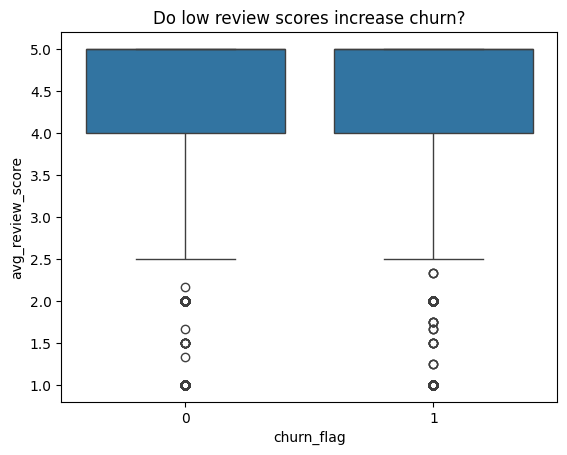

In [15]:
sns.boxplot(
    x="churn_flag",
    y="avg_review_score",
    data=churn_df)
plt.title("Do low review scores increase churn?")

plt.show()

### Total Spent vs Churn

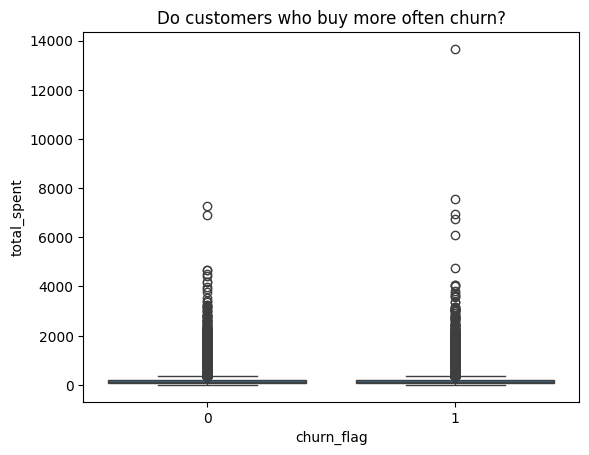

In [16]:
sns.boxplot(
    x="churn_flag",
    y="total_spent",
    data=churn_df)

plt.title("Do customers who buy more often churn?")

plt.show()

*Customers who churned and customers who remained active exhibit very similar spending distributions. The median spending level and interquartile range are nearly identical across both groups, suggesting that total spending alone may not be a strong indicator of customer retention.*

### Correlation Heatmap

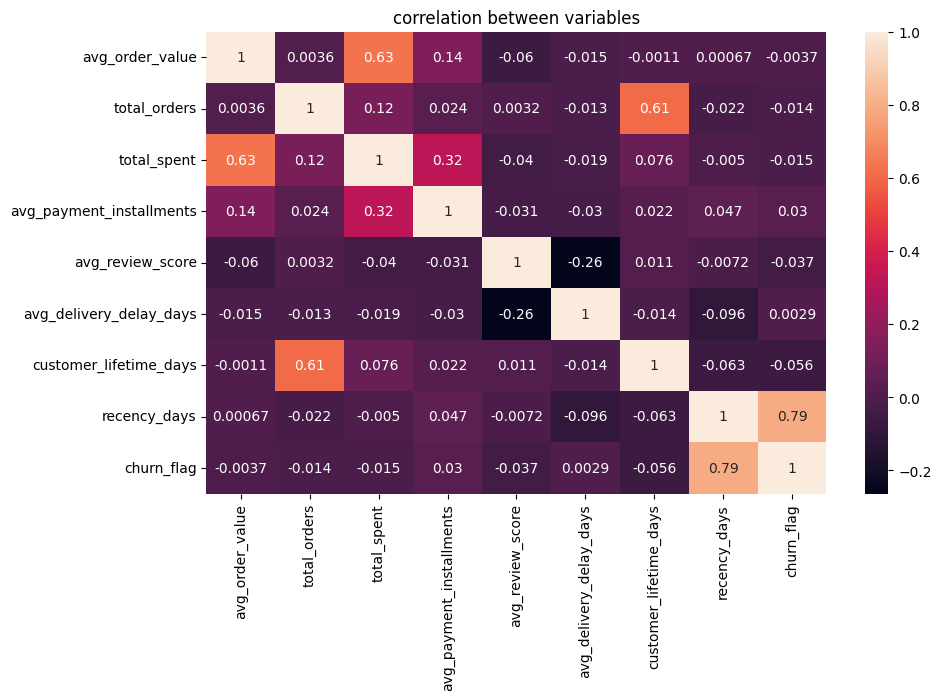

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(
    churn_df.corr(numeric_only=True),
    annot=True)
plt.title("correlation between variables")

plt.show()

*The dataset suggests that customer churn cannot be explained by a single operational metric such as delivery performance, spending level, or review scores. Customer inactivity appears to be driven by a combination of factors not fully captured in the available data.*

<Axes: xlabel='avg_delivery_delay_days', ylabel='avg_review_score'>

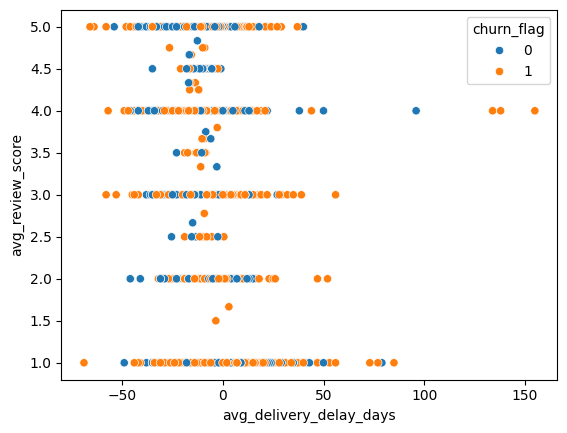

In [18]:
sample_df = churn_df.sample(
    n=10000,
    random_state=42
)
sns.scatterplot(
    x="avg_delivery_delay_days",
    y="avg_review_score",
    hue="churn_flag",
    data=sample_df
)

In [19]:
pd.crosstab(
    churn_df["avg_review_score"],
    churn_df["churn_flag"],
    normalize="index"
).head()

churn_flag,0,1
avg_review_score,,
1.000000,0.364483,0.635517
1.250000,0.000000,1.000000
1.333333,1.000000,0.000000
1.500000,0.625000,0.375000
1.666667,0.250000,0.750000


### Feature Engineering

In [20]:
ml_df = churn_df.drop(["last_purchase", "first_purchase", "recency_days", "customer_unique_id", "customer_state", ], axis=1)

In [21]:
premium_threshold = ml_df["total_spent"].quantile(0.75)

In [22]:
ml_df["premium_customer"] = (ml_df["total_spent"]>= premium_threshold).astype(int)

### Training and Test Dataset

In [23]:
x = ml_df.drop(["churn_flag"], axis=1)
y = ml_df["churn_flag"]

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,  stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model training

### Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000)

In [26]:
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42)

In [28]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

In [30]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### XGBoost

In [31]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [32]:
xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

### LightGBM

In [33]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

In [34]:
lgbm.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Prediction phase

In [35]:
log_predict = log_reg.predict(X_test_scaled)

In [36]:
dt_predict = dt.predict(X_test)

In [37]:
rf_predict = rf.predict(X_test)

In [38]:
xgb_predict = xgb.predict(X_test)

In [39]:
lgbm_predict = lgbm.predict(X_test)

## Probabilities

In [40]:
log_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

dt_prob = dt.predict_proba(X_test)[:, 1]

rf_prob = rf.predict_proba(X_test)[:, 1]

xgb_prob = xgb.predict_proba(X_test)[:, 1]

lgbm_prob = lgbm.predict_proba(X_test)[:, 1]

## Metrics

### Classification Report

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, log_predict))

              precision    recall  f1-score   support

           0       0.59      0.02      0.03      7411
           1       0.61      0.99      0.75     11260

    accuracy                           0.61     18671
   macro avg       0.60      0.50      0.39     18671
weighted avg       0.60      0.61      0.47     18671



In [43]:
print(classification_report(y_test, dt_predict))

              precision    recall  f1-score   support

           0       0.55      0.22      0.31      7411
           1       0.63      0.88      0.74     11260

    accuracy                           0.62     18671
   macro avg       0.59      0.55      0.52     18671
weighted avg       0.60      0.62      0.57     18671



In [44]:
print(classification_report(y_test, rf_predict))

              precision    recall  f1-score   support

           0       0.57      0.19      0.29      7411
           1       0.63      0.90      0.74     11260

    accuracy                           0.62     18671
   macro avg       0.60      0.55      0.52     18671
weighted avg       0.61      0.62      0.56     18671



In [45]:
print(classification_report(y_test, xgb_predict))

              precision    recall  f1-score   support

           0       0.58      0.24      0.34      7411
           1       0.64      0.89      0.74     11260

    accuracy                           0.63     18671
   macro avg       0.61      0.56      0.54     18671
weighted avg       0.62      0.63      0.58     18671



In [46]:
print(classification_report(y_test, lgbm_predict))

              precision    recall  f1-score   support

           0       0.58      0.23      0.33      7411
           1       0.64      0.89      0.74     11260

    accuracy                           0.63     18671
   macro avg       0.61      0.56      0.54     18671
weighted avg       0.61      0.63      0.58     18671



### Confusion Matrix

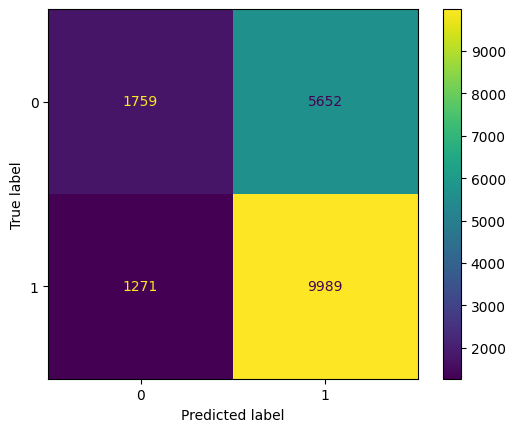

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_predict)

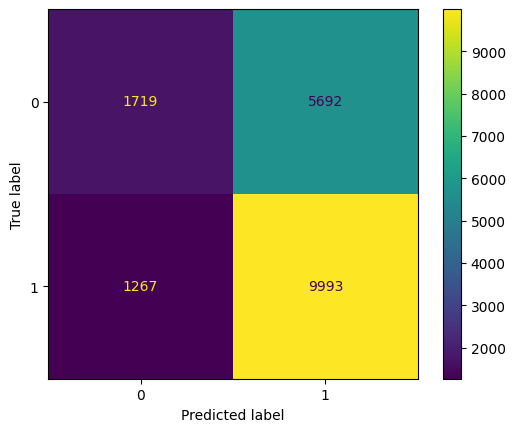

In [48]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lgbm_predict)

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score)

In [51]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_predict),
        accuracy_score(y_test, dt_predict),
        accuracy_score(y_test, rf_predict),
        accuracy_score(y_test, xgb_predict),
        accuracy_score(y_test, lgbm_predict)
    ],
    "Precision": [
        precision_score(y_test, log_predict),
        precision_score(y_test, dt_predict),
        precision_score(y_test, rf_predict),
        precision_score(y_test, xgb_predict),
        precision_score(y_test, lgbm_predict)
    ],
    "Recall": [
        recall_score(y_test, log_predict),
        recall_score(y_test, dt_predict),
        recall_score(y_test, rf_predict),
        recall_score(y_test, xgb_predict),
        recall_score(y_test, lgbm_predict)
    ],
    "F1 Score": [
        f1_score(y_test, log_predict),
        f1_score(y_test, dt_predict),
        f1_score(y_test, rf_predict),
        f1_score(y_test, xgb_predict),
        f1_score(y_test, lgbm_predict)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, lgbm_prob)
    ]
})

In [52]:
results.sort_values(
    by=["ROC-AUC", "F1 Score"],
    ascending=False
).style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
    "ROC-AUC": "{:.3f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBoost,0.629,0.639,0.887,0.743,0.630
4,LightGBM,0.627,0.637,0.887,0.742,0.628
2,Random Forest,0.622,0.630,0.904,0.743,0.614
1,Decision Tree,0.619,0.631,0.884,0.737,0.585
0,Logistic Regression,0.605,0.605,0.993,0.752,0.545


*Among all evaluated models, XGBoost was selected as the final model. Although Logistic Regression achieved the highest Recall (99.3%) and the highest F1 Score (0.752), its ROC-AUC score was only 0.545, indicating a very limited ability to distinguish between churned and active customers. The confusion matrix confirmed that the model classified almost every customer as churned, making it unsuitable for practical decision-making.*

*XGBoost achieved the highest ROC-AUC score (0.630), demonstrating the strongest ability to separate churned customers from active customers. While its F1 Score (0.743) was slightly lower than Logistic Regression, the difference was minimal. In addition, XGBoost provided a more balanced classification performance across both classes, reducing the strong bias toward the churn class observed in Logistic Regression.*

*Therefore, XGBoost was selected as the preferred model because it offered the best trade-off between churn detection performance and class discrimination capability.*

<Axes: ylabel='Model'>

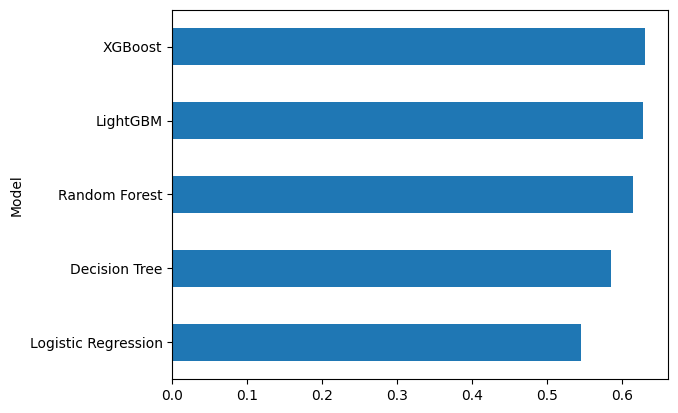

In [53]:
results.set_index("Model")["ROC-AUC"].sort_values().plot(
    kind="barh"
)